In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import mglearn 
import tensorflow as tf 
from sklearn.datasets import fetch_lfw_people 
from sklearn.model_selection import train_test_split 
from sklearn.decomposition import PCA 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.preprocessing import MinMaxScaler 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input, Dense

In [2]:
np.random.seed(180) 
tf.random.set_seed(180)

(2916, 5655)
(2916,)


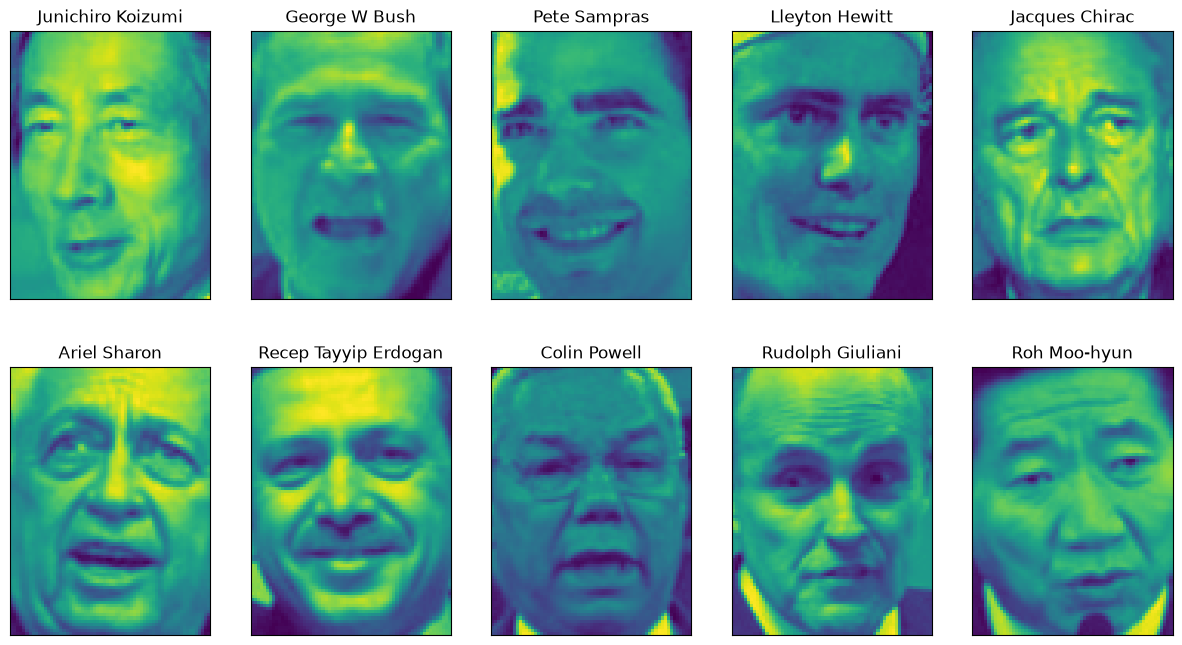

In [8]:
people = fetch_lfw_people( 
min_faces_per_person=20, 
resize=0.7 
) 
print(people.data.shape) 
print(people.target.shape) 
image_shape = people.images[0].shape 
fig, axes = plt.subplots( 
2, 
5, 
figsize=(15,8), 
subplot_kw={'xticks':(), 'yticks':()} 
) 
for target, image, ax in zip( 
people.target, 
        people.images, 
        axes.ravel()): 
 ax.imshow(image) 
 ax.set_title( 
        people.target_names[target] 
    ) 
 
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split( 
    people.data, 
    people.target, 
    test_size=0.2, 
    random_state=20 
) 
 
y_train = y_train.astype(int) 
y_test = y_test.astype(int) 
 
batch_size = len(X_train) 
 
print( 
    X_train.shape, 
    y_train.shape, 
    y_test.shape 
) 
 
print( 
    "people.images.shape: {}".format( 
        people.images.shape 
    ) 
) 
 
print( 
    "Number of classes: {}".format( 
        len(people.target_names) 
    ) 
) 

(2332, 5655) (2332,) (584,)
people.images.shape: (2916, 87, 65)
Number of classes: 58


In [11]:
counts = np.bincount(people.target) 
 
for i, (count, name) in enumerate( 
        zip(counts, people.target_names)): 
 
    print( 
        "{0:25} {1:3}".format(name,count), 
        end=" " 
    ) 
 
    if (i+1)%3 == 0: 
        print()

Alejandro Toledo           39 Alvaro Uribe               35 Amelie Mauresmo            21 
Andre Agassi               36 Ariel Sharon               77 Arnold Schwarzenegger      42 
Atal Bihari Vajpayee       24 Bill Clinton               29 Carlos Menem               21 
Colin Powell              236 David Beckham              31 Donald Rumsfeld           121 
George Robertson           22 George W Bush             530 Gerhard Schroeder         109 
Gloria Macapagal Arroyo    44 Gray Davis                 26 Hamid Karzai               22 
Hans Blix                  39 Hugo Chavez                71 Igor Ivanov                20 
Jack Straw                 28 Jacques Chirac             52 Jean Chretien              55 
Jennifer Aniston           21 Jennifer Capriati          42 Jennifer Lopez             21 
Jeremy Greenstock          24 Jiang Zemin                20 John Ashcroft              53 
John Negroponte            31 Jose Maria Aznar           23 Juan Carlos Ferrero        28 

In [13]:
mask = np.zeros( 
    people.target.shape, 
    dtype=np.bool_ 
) 
 
for target in np.unique(people.target): 
 
    mask[ 
        np.where(people.target == target)[0][:50] 
    ] = True 
X_people = people.data[mask] 
 
y_people = people.target[mask] 
X_people = X_people / 255.0 


In [14]:
X_train, X_test, y_train, y_test = train_test_split( 
    X_people, 
    y_people, 
    stratify=y_people, 
    random_state=0 
) 
knn = KNeighborsClassifier( 
    n_neighbors=1 
) 
 
knn.fit( 
    X_train, 
    y_train 
) 
print( 
    "Test set score of 1-nn: {:.2f}".format( 
        knn.score( 
            X_test, 
            y_test 
        ) 
    ) 
) 

Test set score of 1-nn: 0.24


In [15]:
pca = PCA( 
    n_components=100, 
    whiten=True, 
    random_state=0 
).fit(X_train) 
X_train_pca = pca.transform(X_train) 
X_test_pca = pca.transform(X_test) 
print( 
    "X_train_pca.shape: {}".format( 
        X_train_pca.shape 
    ) 
) 
knn = KNeighborsClassifier( 
    n_neighbors=1 
) 
 
knn.fit( 
    X_train_pca, 
    y_train 
) 
 
print( 
    "Test set accuracy: {:.2f}".format( 
        knn.score( 
            X_test_pca, 
            y_test 
        ) 
    ) 
) 
print( 
"pca.components_.shape: {}".format( 
pca.components_.shape ))

X_train_pca.shape: (1467, 100)
Test set accuracy: 0.31
pca.components_.shape: (100, 5655)


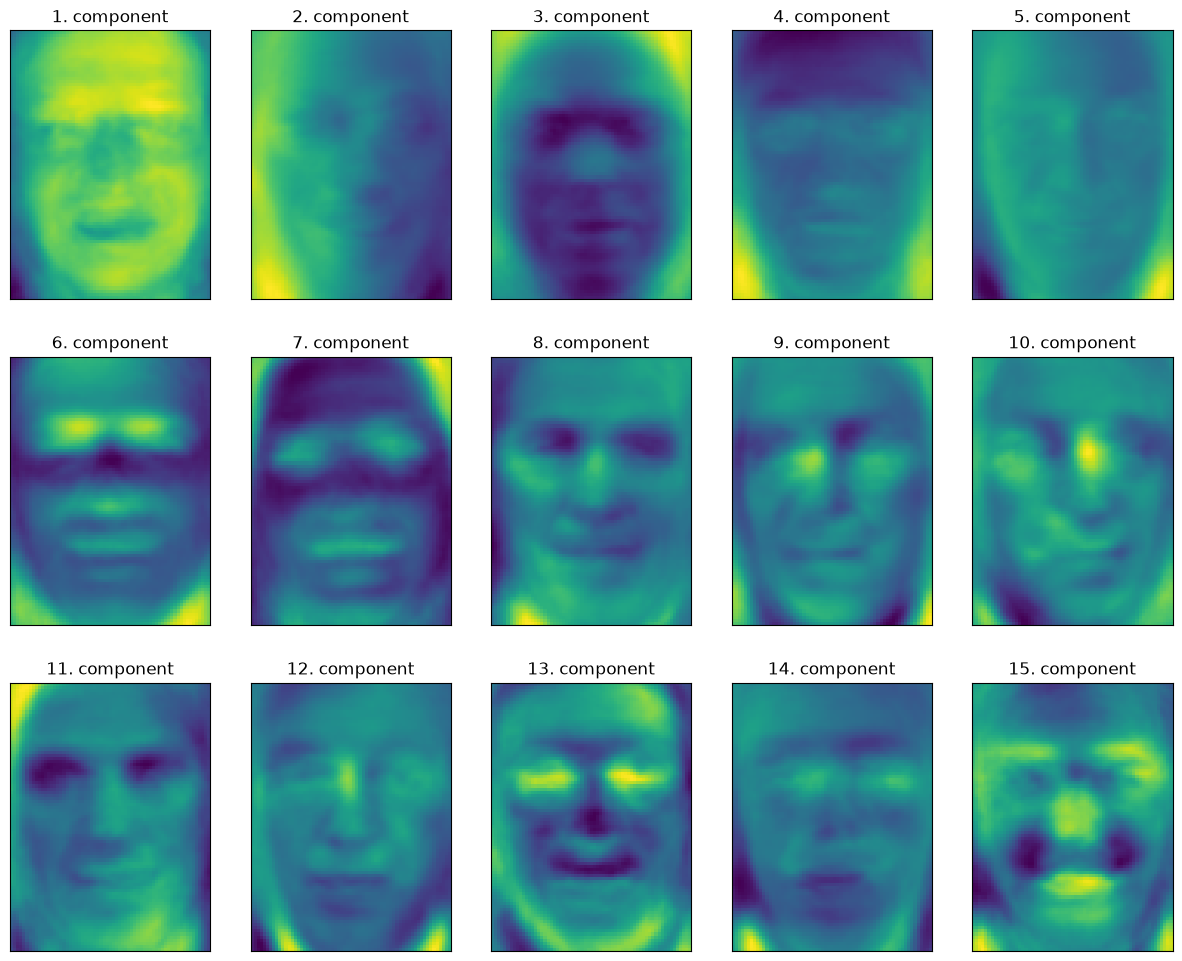

In [17]:
fix, axes = plt.subplots( 
3, 
5, 
figsize=(15,12), 
subplot_kw={'xticks':(), 'yticks':()} 
) 
for i, (component, ax) in enumerate( 
zip(pca.components_, axes.ravel())): 
    ax.imshow( 
    component.reshape(image_shape), 
    cmap='viridis' 
    ) 
    ax.set_title( 
        "{}. component".format(i+1) 
    ) 
 
plt.show()

In [18]:
scaler = MinMaxScaler() 
X_train_scaled = scaler.fit_transform( 
    X_train_pca 
) 
X_test_scaled = scaler.transform( 
    X_test_pca 
)

In [19]:
model = Sequential([ 
 
    Input( 
        shape=(100,) 
    ), 
 
    Dense( 
        300, 
        activation='relu' 
    ), 
 
    Dense( 
        100, 
        activation='relu' 
    ), 
 
    Dense( 
        len(np.unique(y_train)), 
        activation='softmax' 
    ) 
 
])

In [20]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']) 

In [ ]:
history = model.fit( X_train_scaled,y_train,batch_size=50,epochs=20,shuffle=False, verbose=1)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0184 - loss: 4.0568
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0361 - loss: 4.0188
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0361 - loss: 3.9938
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0389 - loss: 3.9721
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0443 - loss: 3.9499
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0675 - loss: 3.9186
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0757 - loss: 3.8833
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0961 - loss: 3.8420
Epoch 9/20
